In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CHEMIN_DS01 = "/content/drive/MyDrive/aeroguard/data/raw/N-CMAPSS_DS01-005.h5"
DOSSIER_PROCESSED = "/content/drive/MyDrive/aeroguard/data/processed"

In [3]:
def lire_noms(f, nom):
    """Lit un tiroir de noms (_var) et renvoie une liste de textes lisibles."""
    valeurs = f[nom][()]
    return [v.decode() if isinstance(v, bytes) else str(v) for v in valeurs]


def charger_ncmapss(chemin, partie="dev"):
    """Charge un fichier N-CMAPSS et renvoie un DataFrame (une ligne par seconde de vol).

    partie : "dev" (développement) ou "test".
    On ne garde pas les capteurs virtuels (X_v), qui n'existent pas sur un vrai avion.
    """
    with h5py.File(chemin, "r") as f:
        A = f[f"A_{partie}"][()]
        W = f[f"W_{partie}"][()]
        X_s = f[f"X_s_{partie}"][()]
        T = f[f"T_{partie}"][()]
        Y = f[f"Y_{partie}"][()]
        colonnes = (lire_noms(f, "A_var") + lire_noms(f, "W_var")
                    + lire_noms(f, "X_s_var") + lire_noms(f, "T_var") + ["RUL"])

    donnees = np.hstack([A, W, X_s, T, Y]).astype("float32")
    df = pd.DataFrame(donnees, columns=colonnes)

    for col in ["unit", "cycle", "Fc", "hs", "RUL"]:
        df[col] = df[col].astype("int32")
    return df

In [4]:
df = charger_ncmapss(CHEMIN_DS01, "dev")
print(df.shape)
print(f"Mémoire utilisée : {df.memory_usage().sum() / 1e9:.2f} Go")
df.head()

(4906636, 33)
Mémoire utilisée : 0.65 Go


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,fan_flow_mod,LPC_eff_mod,LPC_flow_mod,HPC_eff_mod,HPC_flow_mod,HPT_eff_mod,HPT_flow_mod,LPT_eff_mod,LPT_flow_mod,RUL
0,1,1,1,1,3013.0,0.376362,70.311996,522.314758,618.288574,1470.469849,...,0.0,0.0,0.0,0.0,0.0,-0.000604,0.0,0.0,0.0,99
1,1,1,1,1,3020.0,0.376866,70.311996,522.327148,618.296326,1470.415649,...,0.0,0.0,0.0,0.0,0.0,-0.000604,0.0,0.0,0.0,99
2,1,1,1,1,3025.0,0.377685,70.311996,522.371826,618.336487,1470.453857,...,0.0,0.0,0.0,0.0,0.0,-0.000604,0.0,0.0,0.0,99
3,1,1,1,1,3035.0,0.376992,70.399887,522.282410,618.302185,1470.650879,...,0.0,0.0,0.0,0.0,0.0,-0.000604,0.0,0.0,0.0,99
4,1,1,1,1,3043.0,0.377622,70.399887,522.300598,618.345215,1470.640381,...,0.0,0.0,0.0,0.0,0.0,-0.000604,0.0,0.0,0.0,99


In [5]:
print("Moteurs :", sorted(df["unit"].unique()))
print("\nNombre de vols par moteur :")
print(df.groupby("unit")["cycle"].max())

Moteurs : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]

Nombre de vols par moteur :
unit
1    100
2     75
3    100
4     95
5     89
6     94
Name: cycle, dtype: int32


In [6]:
dernier_vol_sain = df[df["hs"] == 1].groupby("unit")["cycle"].max()
nb_vols = df.groupby("unit")["cycle"].max()

bilan = pd.DataFrame({
    "vols au total": nb_vols,
    "dernier vol sain": dernier_vol_sain,
})
bilan["% de vie en bonne santé"] = (100 * bilan["dernier vol sain"] / bilan["vols au total"]).round(0)
bilan

,vols au total,dernier vol sain,% de vie en bonne santé
unit,,,
1,100,36,36.0
2,75,18,24.0
3,100,25,25.0
4,95,37,39.0
5,89,18,20.0
6,94,24,26.0


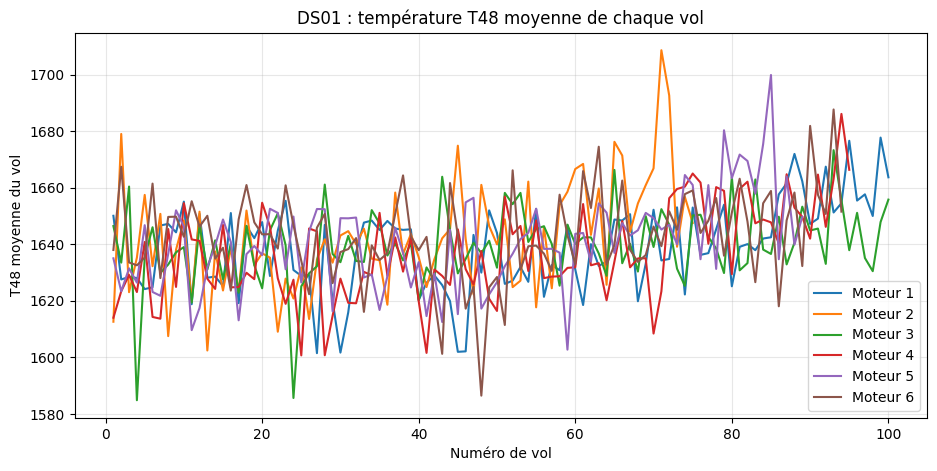

In [7]:
t48_par_vol = df.groupby(["unit", "cycle"])["T48"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
for unit, moteur in t48_par_vol.groupby("unit"):
    ax.plot(moteur["cycle"], moteur["T48"], label=f"Moteur {unit}")

ax.set_title("DS01 : température T48 moyenne de chaque vol")
ax.set_xlabel("Numéro de vol")
ax.set_ylabel("T48 moyenne du vol")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

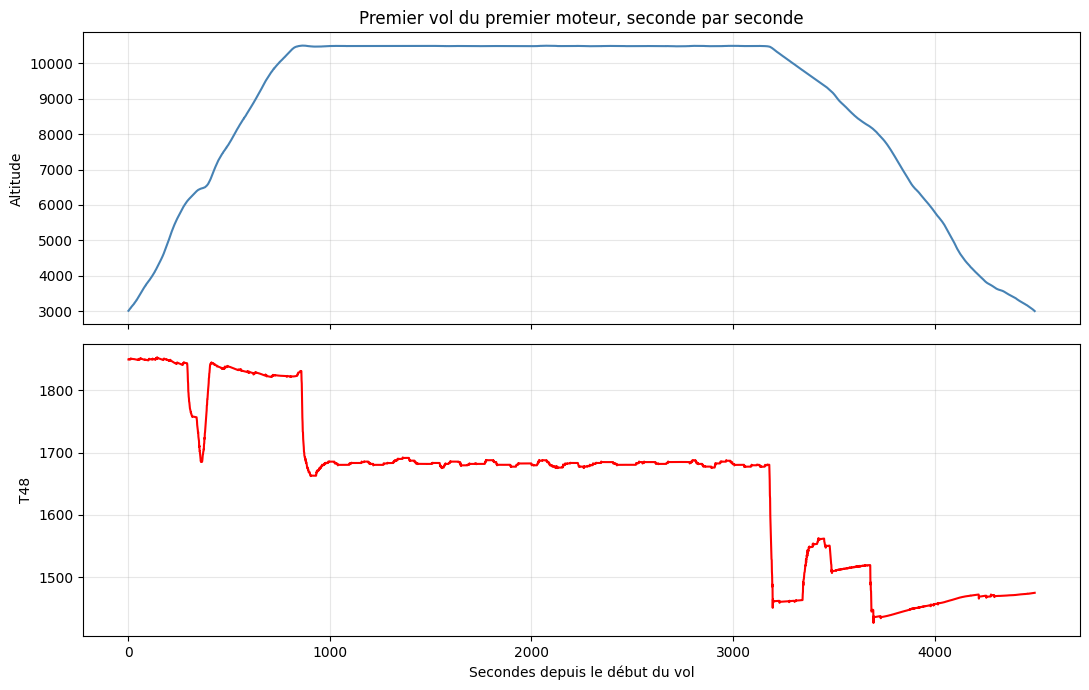

In [8]:
un_vol = df[(df["unit"] == df["unit"].min()) & (df["cycle"] == 1)].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(un_vol.index, un_vol["alt"], color="steelblue")
axes[0].set_ylabel("Altitude")
axes[0].set_title("Premier vol du premier moteur, seconde par seconde")
axes[0].grid(alpha=0.3)

axes[1].plot(un_vol.index, un_vol["T48"], color="red")
axes[1].set_ylabel("T48")
axes[1].set_xlabel("Secondes depuis le début du vol")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
df.to_parquet(f"{DOSSIER_PROCESSED}/ds01_dev.parquet", index=False)

df_test = charger_ncmapss(CHEMIN_DS01, "test")
df_test.to_parquet(f"{DOSSIER_PROCESSED}/ds01_test.parquet", index=False)

!ls -lh /content/drive/MyDrive/aeroguard/data/processed/

total 523M
-rw------- 1 root root 336M Oct  3 16:27 ds01_dev.parquet
-rw------- 1 root root 188M Oct  3 16:28 ds01_test.parquet
